# Notebook 07 — L2 Category Classification
## Extending the Model to the Intermediate Taxonomy Level

**Project**: Cloud-Based ITSM Ticket Classification Platform Using Fine-Tuned Transformer Models  
**Author**: Mohamed A. Elbaz  

---

### Objective

After validating the L1 (6 classes) model, we now extend the taxonomy to **Level 2 (16 classes)**. 

**Workflow**:
1. Load the processed data (L1 and L2 labels).
2. Fine-tune MarBERTv2 with two heads: `label_l1` and `label_l2`.
3. Evaluate if joint training on L1 helps L2 performance.
4. Save artifacts for the next step (L3).

> **Note on MarBERT Load Report**: When loading the model, you may see "UNEXPECTED" keys in the load report (e.g., `cls.predictions.*`). This is **normal behavior**. MarBERTv2 was pre-trained with Masked Language Modeling (MLM) and Next Sentence Prediction (NSP) heads. Since we are using it for classification, these heads are discarded and replaced by our custom task heads. You can safely ignore these warnings.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import torch
import pandas as pd
import pickle
import numpy as np
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
from tqdm.auto import tqdm

from arabic_itsm.data.preprocessing import ArabicTextNormalizer
from arabic_itsm.data.dataset import ITSMDataset
from arabic_itsm.models.classifier import MarBERTClassifier
from arabic_itsm.utils.metrics import compute_classification_metrics

MODEL_NAME = "UBC-NLP/MARBERTv2"
TASKS      = ['l1', 'l2']
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. Data Loading
We use the encoders and splits prepared in Notebook 02.

In [2]:
DATA_DIR = Path('../data/processed')
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'val.csv')

with open(DATA_DIR / 'label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
normalizer = ArabicTextNormalizer()

train_ds = ITSMDataset(train_df, tokenizer, normalizer, label_encoders, tasks=TASKS)
val_ds   = ITSMDataset(val_df, tokenizer, normalizer, label_encoders, tasks=TASKS)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

print(f"Tasks: {TASKS}")
print(f"Classes: {train_ds.num_classes}")

Tasks: ['l1', 'l2']
Classes: {'l1': 6, 'l2': 16}


## 2. Training (L1 + L2 Head)
The training logic follows the multi-head structure established in `src/arabic_itsm/models/classifier.py`.

In [4]:
model = MarBERTClassifier(MODEL_NAME, train_ds.num_classes).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * 5
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.06 * total_steps), total_steps)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

best_l2_f1 = 0.0
OUT_DIR = Path('../models/marbert_l2_best')
OUT_DIR.mkdir(parents=True, exist_ok=True)

for epoch in range(1, 6):
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}"):
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = {f"label_{t}": batch[f"label_{t}"].to(DEVICE) for t in TASKS}

        with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
            out = model(ids, mask, **labels)
            loss = out["loss"]

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad()
        train_loss += loss.item()

    # Validation
    model.eval()
    all_preds = {t: [] for t in TASKS}
    all_labels = {t: [] for t in TASKS}
    with torch.no_grad():
        for batch in val_loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            out = model(ids, mask)
            for t in TASKS:
                all_preds[t].extend(torch.argmax(out[f"logits_{t}"], dim=-1).cpu().numpy())
                all_labels[t].extend(batch[f"label_{t}"].numpy())

    metrics_l1 = compute_classification_metrics(all_labels['l1'], all_preds['l1'])
    metrics_l2 = compute_classification_metrics(all_labels['l2'], all_preds['l2'])
    
    print(f"Epoch {epoch} | Loss: {train_loss/len(train_loader):.4f} | L1 F1: {metrics_l1['macro_f1']:.4f} | L2 F1: {metrics_l2['macro_f1']:.4f}")

    if metrics_l2['macro_f1'] > best_l2_f1:
        best_l2_f1 = metrics_l2['macro_f1']
        torch.save(model.heads.state_dict(), OUT_DIR / "heads.pt")
        model.encoder.save_pretrained(str(OUT_DIR))
        print("  ✓ Saved best L2 checkpoint")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | Details
-------------------------------------------+------------+--------
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |        
bert.embeddings.position_ids               | UNEXPECTED |        
cls.predictions.transform.dense.bias       | UNEXPECTED |        
cls.predictions.bias                       | UNEXPECTED |        
cls.predictions.decoder.weight             | UNEXPECTED |        
cls.predictions.decoder.bias               | UNEXPECTED |        
cls.predictions.transform.dense.weight     | UNEXPECTED |        
cls.seq_relationship.bias                  | UNEXPECTED |        
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |        
cls.seq_relationship.weight                | UNEXPECTED |        

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1:   0%|          | 0/418 [00:00<?, ?it/s]

Epoch 1 | Loss: 1.2438 | L1 F1: 0.8847 | L2 F1: 0.8491


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch 3 | Loss: 0.3582 | L1 F1: 0.8931 | L2 F1: 0.8607


Epoch 4:   0%|          | 0/418 [00:00<?, ?it/s]

Epoch 4 | Loss: 0.3149 | L1 F1: 0.8767 | L2 F1: 0.8580


Epoch 5:   0%|          | 0/418 [00:00<?, ?it/s]

Epoch 5 | Loss: 0.2816 | L1 F1: 0.8819 | L2 F1: 0.8586


## 3. Results & Visual Analysis
We analyze the performance on the 16 L2 classes and check for common confusions.

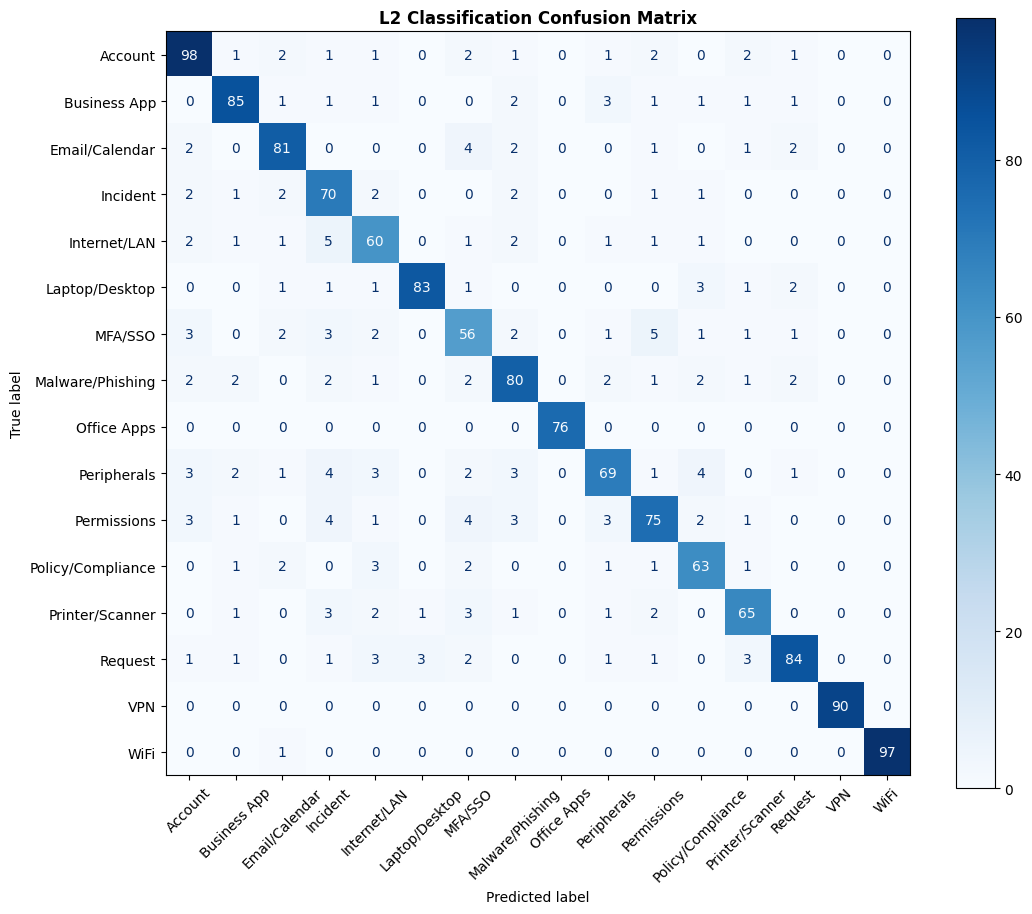


--- L2 Performance Insights ---
L2 categories are more granular (16 classes vs 6). Common confusions often happen between parent-child nodes if the model isn't yet certain of the sub-category nuances.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

l2_names = label_encoders['l2'].classes_
cm = confusion_matrix(all_labels['l2'], all_preds['l2'])

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=l2_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('L2 Classification Confusion Matrix', fontweight='bold')
plt.savefig('../results/figures/07_l2_confusion_matrix.png', bbox_inches='tight')
plt.show()

print("\n--- L2 Performance Insights ---")
print("L2 categories are more granular (16 classes vs 6). Common confusions often happen between parent-child nodes if the model isn't yet certain of the sub-category nuances.")